In [13]:
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri.cm as cm

In [33]:
path = "/users/rpayne/data/unproc/WRF-UBC/ubc_wrf_staticfields_d03.nc"
wrf_ubc_static = xr.open_dataset(path)
varsso = wrf_ubc_static["VAR_SSO"].values[0] / 1e3
hgt = wrf_ubc_static["HGT"].values[0]

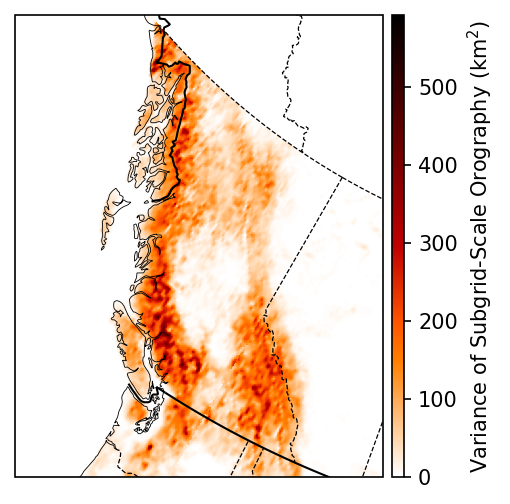

In [35]:
# Create a figure
proj = ccrs.Stereographic(
    central_latitude=90.0,
    central_longitude=wrf_ubc_static.STAND_LON,
    true_scale_latitude=wrf_ubc_static.TRUELAT1,
)
lon_ubc = wrf_ubc_static['XLONG'].values.squeeze()
lat_ubc = wrf_ubc_static['XLAT'].values.squeeze()
fig, ax = plt.subplots(subplot_kw={"projection": proj},figsize=(4,4),dpi=150)
cmap =  ListedColormap(plt.cm.gist_heat_r(np.linspace(0, 1, 256)))

# Plot using pcolormesh
mesh = ax.pcolormesh(lon_ubc, lat_ubc, varsso, transform=ccrs.PlateCarree(), shading='auto', cmap=cmap)
ax.add_feature(cfeature.BORDERS, linewidth=1, zorder=1)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=1)
ax.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=1)

# Add coastline as contour of the height field:
# ax.contour(lon_ubc, lat_ubc, hgt, levels=[0], colors='k', linewidths=0.4, transform=ccrs.PlateCarree(), zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=.4, zorder=1) # Coastlines

cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, aspect=40)
cbar.set_label('Variance of Subgrid-Scale Orography (km$^2$)')

plt.show()